In [1]:
!pip install ucimlrepo xgboost scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, average_precision_score,
                             ConfusionMatrixDisplay)
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, average_precision_score, PrecisionRecallDisplay

# Reproducibility
SEED = 42
np.random.seed(SEED)

In [3]:
bank = fetch_ucirepo(id=222)
X = bank.data.features.copy()
y = bank.data.targets.copy()

print("Features shape:", X.shape)
print("Target distribution:\n", y['y'].value_counts())
print("\nFeature dtypes:\n", X.dtypes.value_counts())
print("\nMissing values:\n", X.isnull().sum().sum())

Features shape: (45211, 16)
Target distribution:
 y
no     39922
yes     5289
Name: count, dtype: int64

Feature dtypes:
 object    9
int64     7
Name: count, dtype: int64

Missing values:
 52124


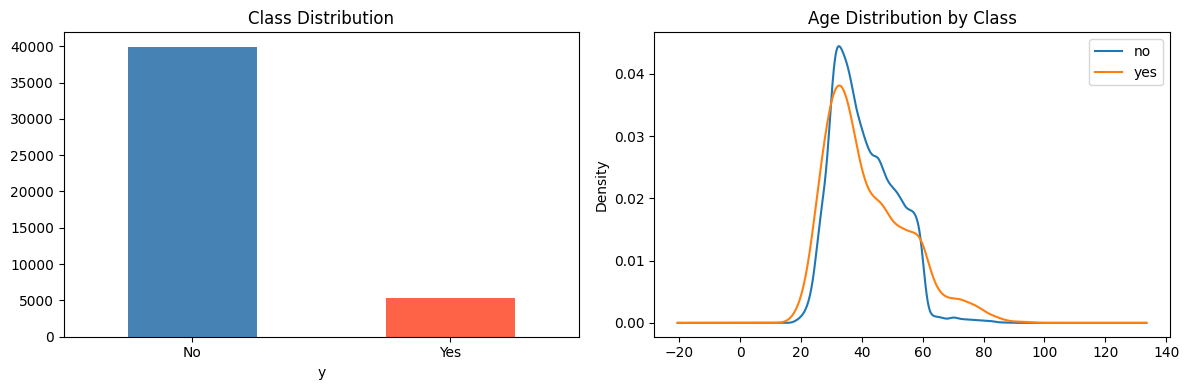

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
y['y'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Age distribution by class
X_eda = X.copy()
X_eda['target'] = y['y'].values
X_eda.groupby('target')['age'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Age Distribution by Class')

plt.tight_layout()
plt.savefig('eda.png', dpi=150)
plt.show()

In [5]:
# Treat "unknown" as a valid category — don't impute it
# One-hot encode all categoricals
X_encoded = pd.get_dummies(X, drop_first=True)
y_binary = (y['y'] == 'yes').astype(int)

print("Encoded shape:", X_encoded.shape)
print("Columns:", X_encoded.columns.tolist())

# 70 / 15 / 15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y_binary,
    test_size=0.30, random_state=SEED, stratify=y_binary
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Val positive rate:   {y_val.mean():.3f}")
print(f"Test positive rate:  {y_test.mean():.3f}")

# Scale for MLP — fit ONLY on train
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

Encoded shape: (45211, 38)
Columns: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success']

Train: (31647, 38), Val: (6782, 38), Test: (6782, 38)
Train positive rate: 0.117
Val positive rate:   0.117
Test positive rate:  0.117


In [6]:
print(len(X_train)/len(X_encoded),
      len(X_val)/len(X_encoded),
      len(X_test)/len(X_encoded))

0.6999845170423127 0.15000774147884363 0.15000774147884363


In [7]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
# Should be ~7.5 — tells XGBoost to weight the minority class accordingly

scale_pos_weight: 7.55


In [8]:
model_xgb = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    early_stopping_rounds=50,
    random_state=SEED,
    use_label_encoder=False
)

start = time.time()
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)
xgb_train_time = time.time() - start
best_round = model_xgb.best_iteration

print(f"Best round: {best_round} / 1500")
print(f"Training time: {xgb_train_time:.2f}s")
print(f"Converged early: {best_round < 1400}")

Best round: 961 / 1500
Training time: 30.82s
Converged early: True


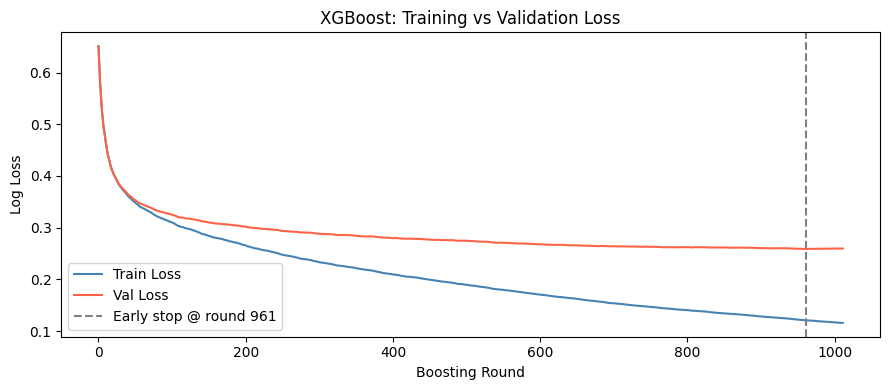

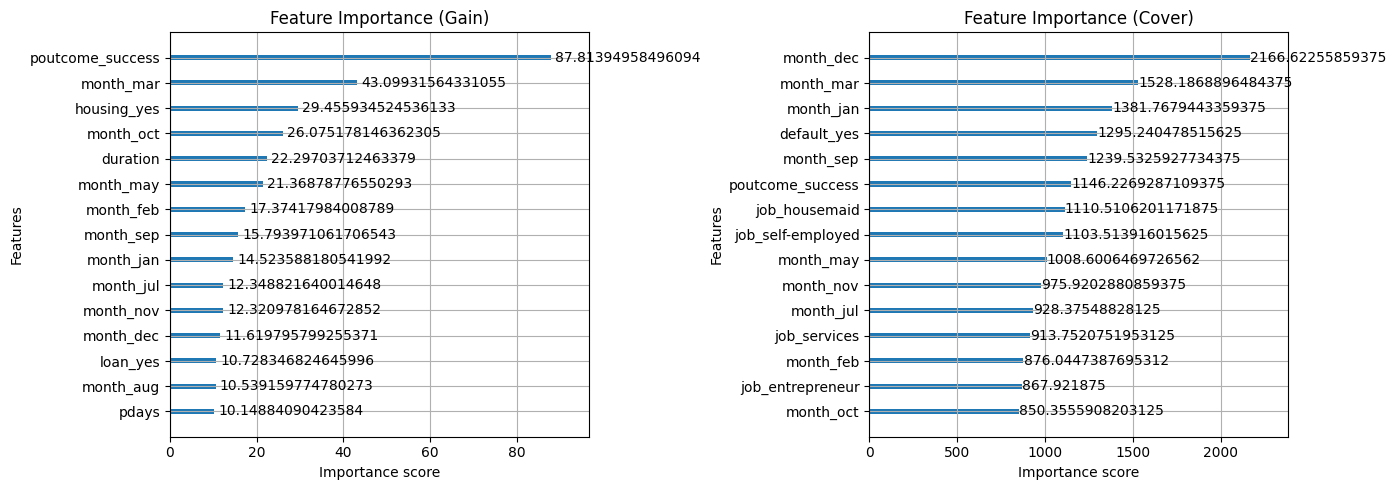

lr=0.01 → best round: 1499, best val loss: 0.3064
lr=0.10 → best round:  968, best val loss: 0.2592
lr=0.30 → best round:  310, best val loss: 0.2714


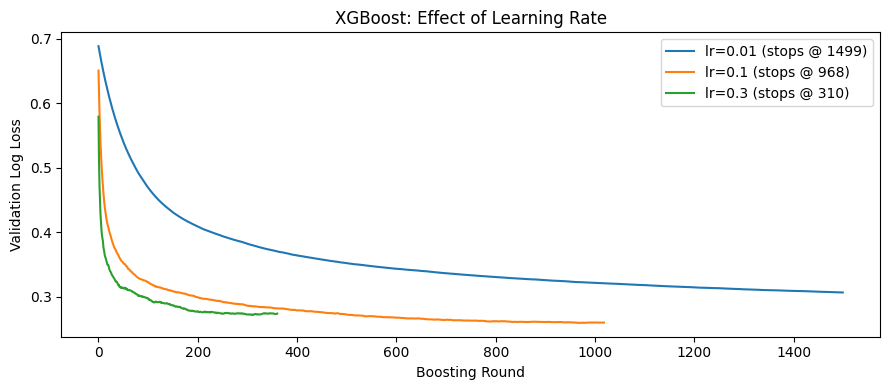


=== XGBoost Final Validation Performance ===
              precision    recall  f1-score   support

          No       0.96      0.91      0.93      5988
         Yes       0.51      0.73      0.60       794

    accuracy                           0.89      6782
   macro avg       0.74      0.82      0.77      6782
weighted avg       0.91      0.89      0.90      6782

AUC-PR:        0.5836
Training time: 30.82s


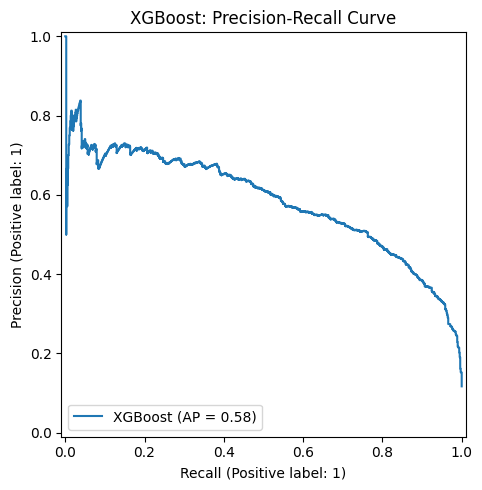

In [9]:
# --- Loss curve ---
results = model_xgb.evals_result()
train_loss = results['validation_0']['logloss']
val_loss   = results['validation_1']['logloss']

plt.figure(figsize=(9, 4))
plt.plot(train_loss, label='Train Loss', color='steelblue')
plt.plot(val_loss,   label='Val Loss',   color='tomato')
plt.axvline(best_round, linestyle='--', color='gray',
            label=f'Early stop @ round {best_round}')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('XGBoost: Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('xgb_loss_curve.png', dpi=150)
plt.show()

# --- Feature importance (gain) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
xgb.plot_importance(model_xgb, ax=axes[0], max_num_features=15,
                    importance_type='gain',  title='Feature Importance (Gain)')
xgb.plot_importance(model_xgb, ax=axes[1], max_num_features=15,
                    importance_type='cover', title='Feature Importance (Cover)')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()

# --- Learning rate comparison (replot cleanly) ---
lr_values = [0.01, 0.1, 0.3]
lr_data = {}

for lr in lr_values:
    m = xgb.XGBClassifier(
        n_estimators=1500,
        learning_rate=lr,
        max_depth=5,
        subsample=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        early_stopping_rounds=50,
        random_state=SEED,
        use_label_encoder=False
    )
    m.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)
    lr_data[lr] = {
        'val_loss':   m.evals_result()['validation_0']['logloss'],
        'best_round': m.best_iteration,
        'best_loss':  m.best_score
    }
    print(f"lr={lr:.2f} → best round: {m.best_iteration:>4}, "
          f"best val loss: {m.best_score:.4f}")

plt.figure(figsize=(9, 4))
for lr, res in lr_data.items():
    plt.plot(res['val_loss'],
             label=f'lr={lr} (stops @ {res["best_round"]})')
plt.xlabel('Boosting Round')
plt.ylabel('Validation Log Loss')
plt.title('XGBoost: Effect of Learning Rate')
plt.legend()
plt.tight_layout()
plt.savefig('xgb_lr_comparison.png', dpi=150)
plt.show()

# --- Final evaluation ---
y_pred_xgb  = model_xgb.predict(X_val)
y_proba_xgb = model_xgb.predict_proba(X_val)[:, 1]

print("\n=== XGBoost Final Validation Performance ===")
print(classification_report(y_val, y_pred_xgb, target_names=['No', 'Yes']))
print(f"AUC-PR:        {average_precision_score(y_val, y_proba_xgb):.4f}")
print(f"Training time: {xgb_train_time:.2f}s")

# PR curve
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_val, y_proba_xgb, ax=ax, name='XGBoost')
ax.set_title('XGBoost: Precision-Recall Curve')
plt.tight_layout()
plt.savefig('xgb_pr_curve.png', dpi=150)
plt.show()

## **MLP**

(64,)                | iters:   35 | F1: 0.4744 | AUC-PR: 0.5591 | time: 4.85s
(128, 64)            | iters:   41 | F1: 0.5280 | AUC-PR: 0.5881 | time: 19.20s
(256, 128, 64)       | iters:   33 | F1: 0.5059 | AUC-PR: 0.5621 | time: 34.58s


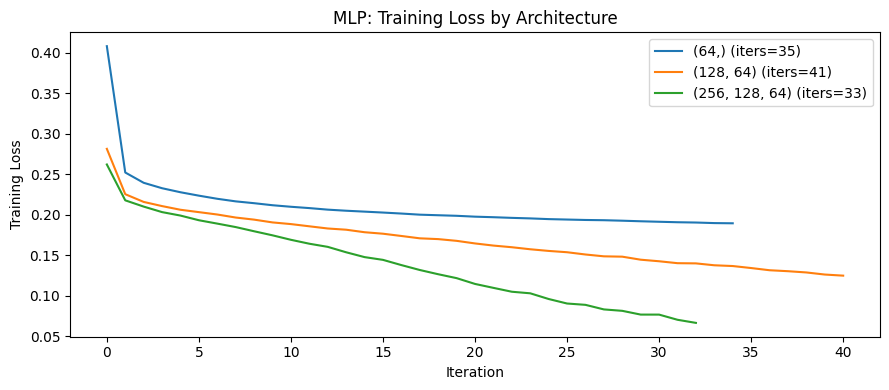

In [10]:
architectures = {
    '(64,)':          (64,),
    '(128, 64)':      (128, 64),
    '(256, 128, 64)': (256, 128, 64),
}

mlp_results = {}

for name, layers in architectures.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,   # more patience
        tol=1e-5,              # tighter tolerance — won't stop as early
        random_state=SEED
    )
    start = time.time()
    mlp.fit(X_train_sc, y_train)
    elapsed = time.time() - start

    y_pred  = mlp.predict(X_val_sc)
    y_proba = mlp.predict_proba(X_val_sc)[:, 1]

    mlp_results[name] = {
        'model':   mlp,
        'time':    elapsed,
        'f1':      f1_score(y_val, y_pred),
        'auc_pr':  average_precision_score(y_val, y_proba),
        'loss':    mlp.loss_curve_,
        'iters':   mlp.n_iter_,
    }
    print(f"{name:20s} | iters: {mlp.n_iter_:>4} | "
          f"F1: {mlp_results[name]['f1']:.4f} | "
          f"AUC-PR: {mlp_results[name]['auc_pr']:.4f} | "
          f"time: {elapsed:.2f}s")

# Plot loss curves
plt.figure(figsize=(9, 4))
for name, res in mlp_results.items():
    plt.plot(res['loss'], label=f'{name} (iters={res["iters"]})')
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('MLP: Training Loss by Architecture')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_architecture_loss.png', dpi=150)
plt.show()

relu  / lr=0.001          | iters:   31 | F1: 0.5280 | AUC-PR: 0.5881
relu  / lr=0.01           | iters:   24 | F1: 0.4977 | AUC-PR: 0.5833
tanh  / lr=0.001          | iters:   31 | F1: 0.5244 | AUC-PR: 0.5764
tanh  / lr=0.01           | iters:   24 | F1: 0.4973 | AUC-PR: 0.5783


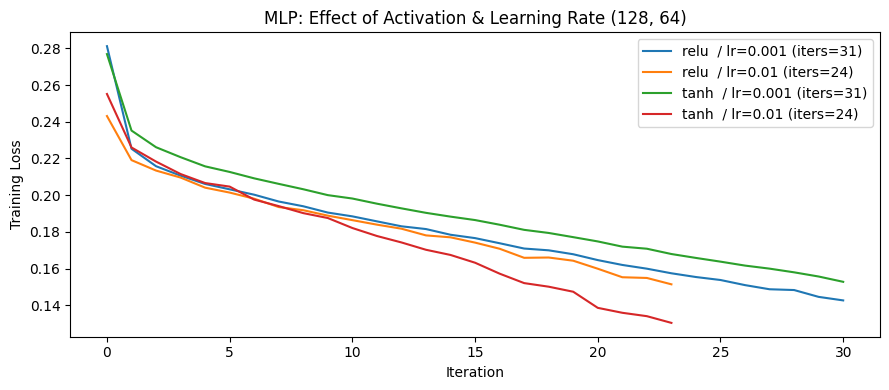

In [11]:
configs = {
    'relu  / lr=0.001': ('relu',  0.001),
    'relu  / lr=0.01':  ('relu',  0.01),
    'tanh  / lr=0.001': ('tanh',  0.001),
    'tanh  / lr=0.01':  ('tanh',  0.01),
}

activation_results = {}

for name, (act, lr) in configs.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),  # fix architecture, vary activation/lr
        activation=act,
        learning_rate_init=lr,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=SEED
    )
    mlp.fit(X_train_sc, y_train)

    y_pred  = mlp.predict(X_val_sc)
    y_proba = mlp.predict_proba(X_val_sc)[:, 1]

    activation_results[name] = {
        'model':  mlp,
        'f1':     f1_score(y_val, y_pred),
        'auc_pr': average_precision_score(y_val, y_proba),
        'loss':   mlp.loss_curve_,
        'iters':  mlp.n_iter_,
    }
    print(f"{name:25s} | iters: {mlp.n_iter_:>4} | "
          f"F1: {activation_results[name]['f1']:.4f} | "
          f"AUC-PR: {activation_results[name]['auc_pr']:.4f}")

# Plot
plt.figure(figsize=(9, 4))
for name, res in activation_results.items():
    plt.plot(res['loss'], label=f'{name} (iters={res["iters"]})')
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('MLP: Effect of Activation & Learning Rate (128, 64)')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_activation_lr.png', dpi=150)
plt.show()

Best architecture: (128, 64)

=== MLP Final Validation Performance ===
              precision    recall  f1-score   support

          No       0.93      0.96      0.95      5988
         Yes       0.61      0.46      0.53       794

    accuracy                           0.90      6782
   macro avg       0.77      0.71      0.74      6782
weighted avg       0.89      0.90      0.90      6782

AUC-PR:        0.5881
Training time: 19.20s


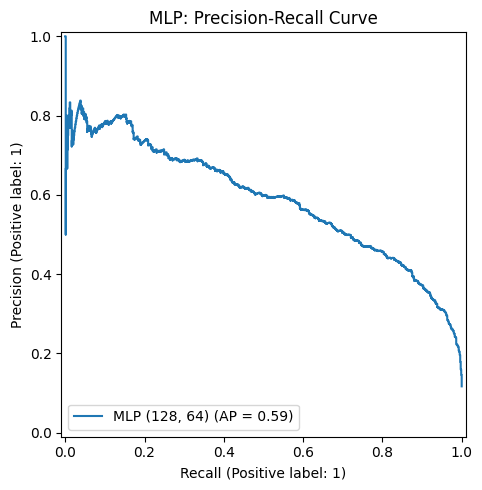

In [12]:
# Pick best by AUC-PR from architecture search
best_name = max(mlp_results, key=lambda k: mlp_results[k]['auc_pr'])
best_mlp  = mlp_results[best_name]['model']
mlp_train_time = mlp_results[best_name]['time']

print(f"Best architecture: {best_name}")

y_pred_mlp  = best_mlp.predict(X_val_sc)
y_proba_mlp = best_mlp.predict_proba(X_val_sc)[:, 1]

print("\n=== MLP Final Validation Performance ===")
print(classification_report(y_val, y_pred_mlp, target_names=['No', 'Yes']))
print(f"AUC-PR:        {average_precision_score(y_val, y_proba_mlp):.4f}")
print(f"Training time: {mlp_train_time:.2f}s")

# PR curve
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_val, y_proba_mlp, ax=ax, name=f'MLP {best_name}')
ax.set_title('MLP: Precision-Recall Curve')
plt.tight_layout()
plt.savefig('mlp_pr_curve.png', dpi=150)
plt.show()

In [13]:
# Lock in best MLP for comparison
# Use best model from architecture search (selected by AUC-PR)
best_name = max(mlp_results, key=lambda k: mlp_results[k]['auc_pr'])
best_mlp  = mlp_results[best_name]['model']
mlp_train_time = mlp_results[best_name]['time']

y_pred_mlp  = best_mlp.predict(X_val_sc)
y_proba_mlp = best_mlp.predict_proba(X_val_sc)[:, 1]

print(f"Best architecture: {best_name}")
print(f"Training time: {mlp_train_time:.2f}s")

Best architecture: (128, 64)
Training time: 19.20s


## **Comparison**

In [14]:
# ── Test set predictions ──────────────────────────────────────────
y_pred_xgb_test  = model_xgb.predict(X_test)
y_proba_xgb_test = model_xgb.predict_proba(X_test)[:, 1]

y_pred_mlp_test  = best_mlp.predict(X_test_sc)
y_proba_mlp_test = best_mlp.predict_proba(X_test_sc)[:, 1]

# ── Metrics function ──────────────────────────────────────────────
def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy':       round(accuracy_score(y_true, y_pred), 4),
        'Precision':      round(precision_score(y_true, y_pred), 4),
        'Recall':         round(recall_score(y_true, y_pred), 4),
        'F1':             round(f1_score(y_true, y_pred), 4),
        'AUC-PR':         round(average_precision_score(y_true, y_proba), 4),
    }

xgb_metrics = get_metrics(y_test, y_pred_xgb_test, y_proba_xgb_test)
mlp_metrics = get_metrics(y_test, y_pred_mlp_test, y_proba_mlp_test)

# ── Comparison table ──────────────────────────────────────────────
comparison = pd.DataFrame({
    'XGBoost': xgb_metrics,
    'MLP':     mlp_metrics,
})
comparison['Winner'] = comparison.apply(
    lambda row: 'XGBoost' if row['XGBoost'] > row['MLP']
    else ('MLP' if row['MLP'] > row['XGBoost'] else 'Tie'), axis=1)

print("=" * 50)
print("       GBDT vs MLP — Test Set Comparison")
print("=" * 50)
print(comparison.to_string())
print(f"\nXGBoost training time: {xgb_train_time:.2f}s")
print(f"MLP training time:     {mlp_train_time:.2f}s")

       GBDT vs MLP — Test Set Comparison
           XGBoost     MLP   Winner
Accuracy    0.8841  0.8988      MLP
Precision   0.5031  0.5876      MLP
Recall      0.7226  0.4527  XGBoost
F1          0.5932  0.5114  XGBoost
AUC-PR      0.5636  0.5689      MLP

XGBoost training time: 30.82s
MLP training time:     19.20s


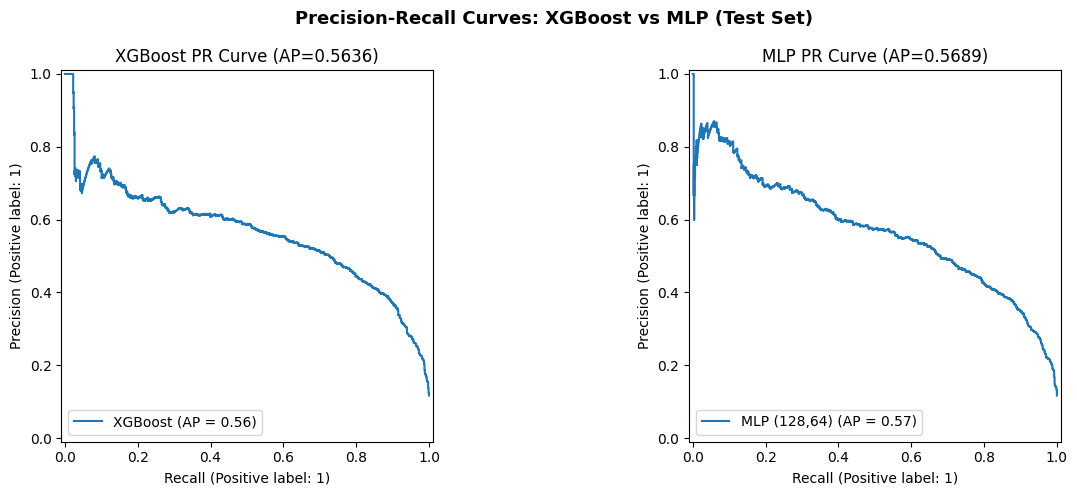

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# XGBoost PR
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_xgb_test, ax=axes[0], name='XGBoost')
axes[0].set_title(f'XGBoost PR Curve (AP={xgb_metrics["AUC-PR"]})')

# MLP PR
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba_mlp_test, ax=axes[1], name='MLP (128,64)')
axes[1].set_title(f'MLP PR Curve (AP={mlp_metrics["AUC-PR"]})')

plt.suptitle('Precision-Recall Curves: XGBoost vs MLP (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_pr_curves.png', dpi=150)
plt.show()

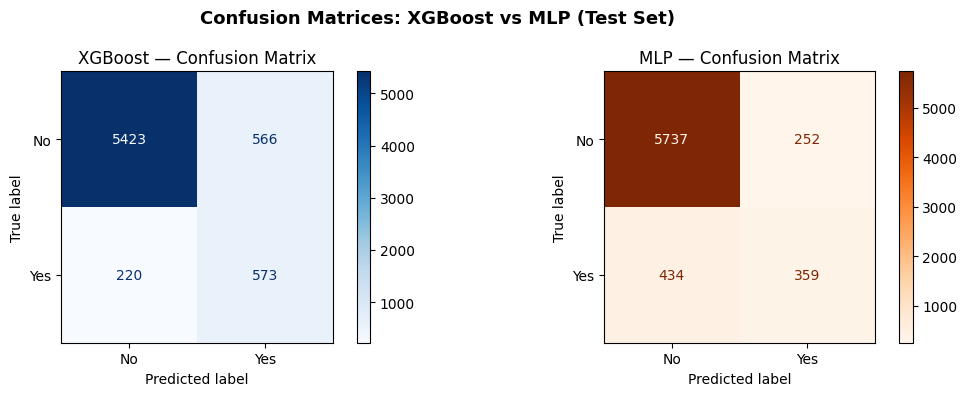

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_test,
    display_labels=['No', 'Yes'],
    cmap='Blues', ax=axes[0])
axes[0].set_title('XGBoost — Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp_test,
    display_labels=['No', 'Yes'],
    cmap='Oranges', ax=axes[1])
axes[1].set_title('MLP — Confusion Matrix')

plt.suptitle('Confusion Matrices: XGBoost vs MLP (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_confusion_matrices.png', dpi=150)
plt.show()

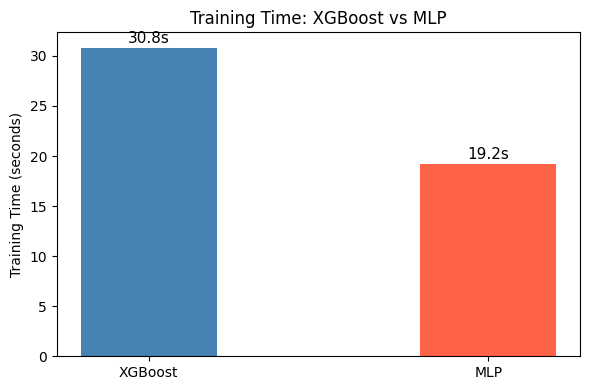

In [17]:
plt.figure(figsize=(6, 4))
models = ['XGBoost', 'MLP']
times  = [xgb_train_time, mlp_train_time]
colors = ['steelblue', 'tomato']

bars = plt.bar(models, times, color=colors, width=0.4)
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{t:.1f}s', ha='center', fontsize=11)

plt.ylabel('Training Time (seconds)')
plt.title('Training Time: XGBoost vs MLP')
plt.tight_layout()
plt.savefig('comparison_training_time.png', dpi=150)
plt.show()